# Análisis de Permisos de Construcción en Ecuador (2011–2014)

**Fuente:** INEC — Encuesta de Edificaciones (Permisos de Construcción). Licencia CC BY 4.0.

Este notebook explora ~109.500 permisos de construcción reales para responder preguntas de negocio sobre inversión por provincia, tendencias temporales, mezcla residencial/no residencial, materiales por región y estacionalidad.

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
FIG = Path('../reports/figuras'); FIG.mkdir(parents=True, exist_ok=True)
con = sqlite3.connect('../data/construccion.db')
print('Conectado. Total permisos:',
      con.execute('SELECT COUNT(*) FROM permisos').fetchone()[0])

Conectado. Total permisos: 109552


## 1. Provincias con más permisos

,provincia,num_permisos
0,Guayas,19901
1,Pichincha,13311
2,Manabi,9769
3,Azuay,8571
4,Loja,6824
5,El Oro,6401
6,Tungurahua,6313
7,Imbabura,6097
8,Los Rios,4821
9,Cotopaxi,3859


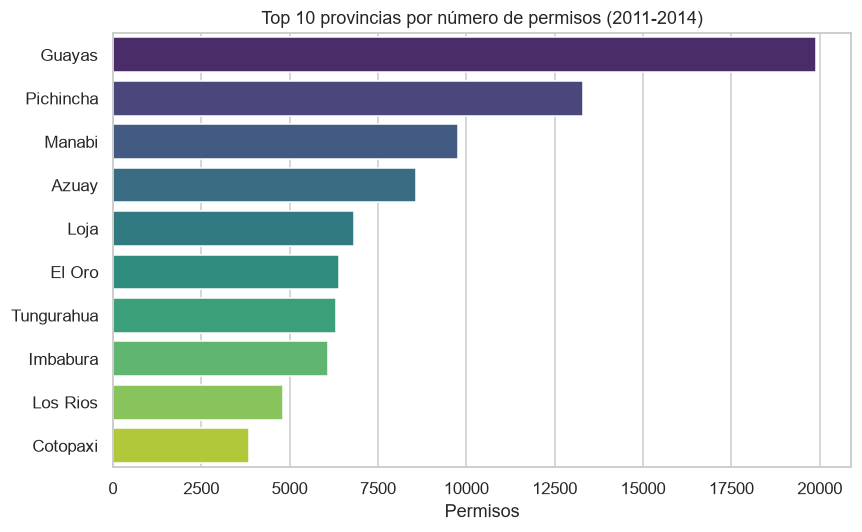

In [2]:
q1 = '''SELECT d.provincia, COUNT(*) num_permisos
        FROM permisos p JOIN dim_provincia d ON p.provincia_id=d.provincia_id
        GROUP BY d.provincia ORDER BY num_permisos DESC LIMIT 10'''
df1 = pd.read_sql(q1, con)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(df1, y='provincia', x='num_permisos', hue='provincia',
            palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 provincias por número de permisos (2011-2014)')
ax.set_xlabel('Permisos'); ax.set_ylabel('')
fig.tight_layout(); fig.savefig(FIG/'01_provincias.png', bbox_inches='tight')
df1

## 2. Evolución anual: permisos y valor de edificación

,anio,num_permisos,valor_millones_usd
0,2011,29550,2308.977720
1,2012,29050,3095.282671
2,2013,26379,3626.791042
3,2014,24573,3170.253384


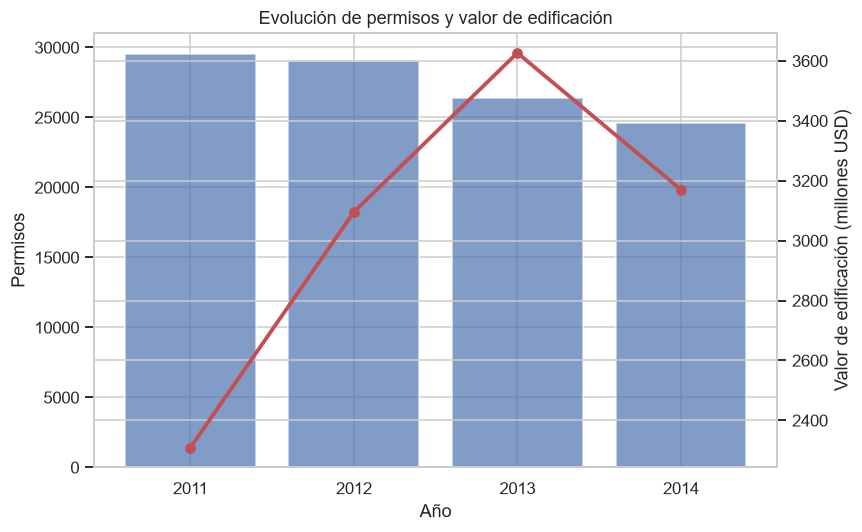

In [3]:
q2 = '''SELECT anio, COUNT(*) num_permisos,
        SUM(valor_edificacion_usd)/1e6 valor_millones_usd
        FROM permisos GROUP BY anio ORDER BY anio'''
df2 = pd.read_sql(q2, con)
fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(df2['anio'], df2['num_permisos'], color='#4C72B0', alpha=0.7, label='Permisos')
ax1.set_ylabel('Permisos'); ax1.set_xlabel('Año'); ax1.set_xticks(df2['anio'])
ax2 = ax1.twinx()
ax2.plot(df2['anio'], df2['valor_millones_usd'], color='#C44E52', marker='o',
         linewidth=2.5, label='Valor (M USD)')
ax2.set_ylabel('Valor de edificación (millones USD)')
ax1.set_title('Evolución de permisos y valor de edificación')
fig.tight_layout(); fig.savefig(FIG/'02_evolucion.png', bbox_inches='tight')
df2

## 3. Superficie residencial vs no residencial

,residencial,no_residencial
anio,,
2011,8.071402,1.754965
2012,9.134136,2.790214
2013,9.820284,2.186172
2014,8.311584,1.705190


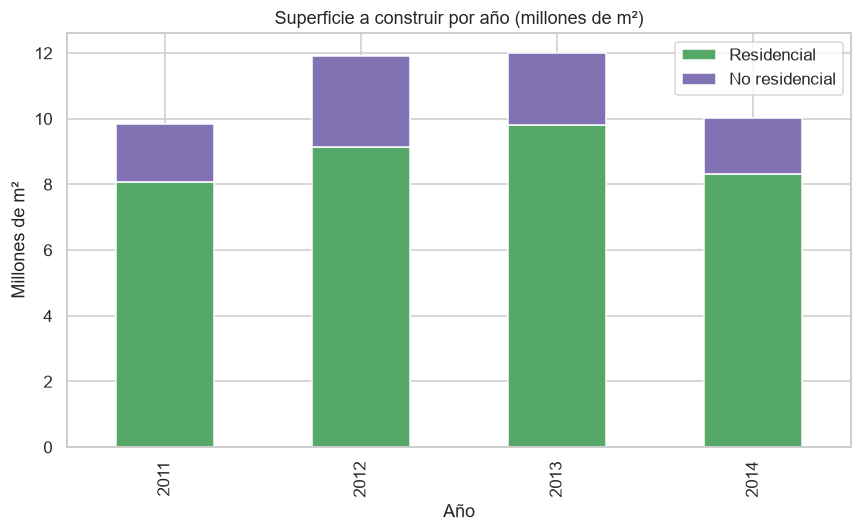

In [4]:
q3 = '''SELECT anio,
        SUM(superficie_residencial_m2)/1e6 residencial,
        SUM(superficie_no_residencial_m2)/1e6 no_residencial
        FROM permisos GROUP BY anio ORDER BY anio'''
df3 = pd.read_sql(q3, con).set_index('anio')
fig, ax = plt.subplots(figsize=(8,5))
df3.plot(kind='bar', stacked=True, ax=ax, color=['#55A868','#8172B3'])
ax.set_title('Superficie a construir por año (millones de m²)')
ax.set_ylabel('Millones de m²'); ax.set_xlabel('Año')
ax.legend(['Residencial','No residencial'])
fig.tight_layout(); fig.savefig(FIG/'03_residencial.png', bbox_inches='tight')
df3

## 4. Material de estructura por región

material_estructura,Hormigon armado,Madera,Metalica,No aplica,Otros
region,,,,,
Amazonia,90.8,1.0,7.4,0.7,0.1
Costa,93.9,0.1,1.7,4.2,0.0
Insular,96.7,0.4,0.7,1.7,0.5
Sierra,93.6,0.3,5.3,0.6,0.1


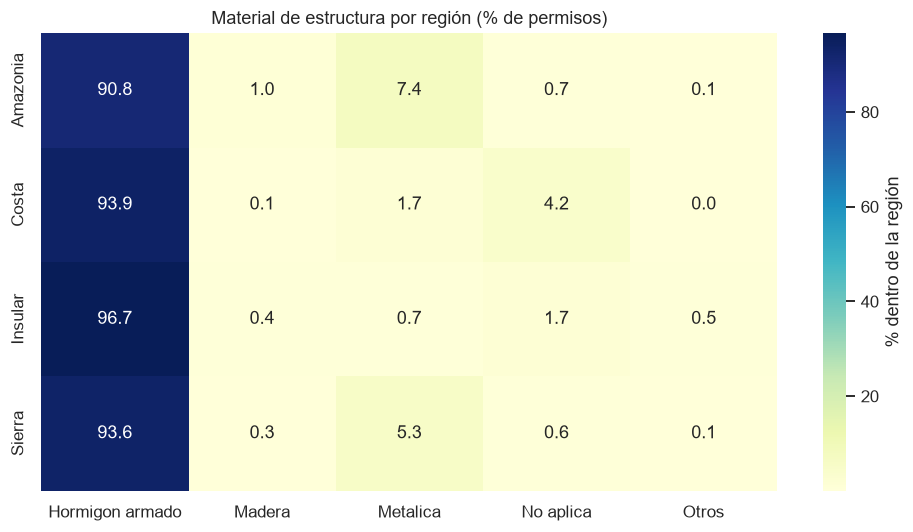

In [5]:
q4 = '''SELECT d.region, p.material_estructura, COUNT(*) n
        FROM permisos p JOIN dim_provincia d ON p.provincia_id=d.provincia_id
        WHERE p.material_estructura IS NOT NULL
        GROUP BY d.region, p.material_estructura'''
df4 = pd.read_sql(q4, con)
piv = df4.pivot_table(index='region', columns='material_estructura',
                      values='n', fill_value=0)
pct = piv.div(piv.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label':'% dentro de la región'})
ax.set_title('Material de estructura por región (% de permisos)')
ax.set_xlabel(''); ax.set_ylabel('')
fig.tight_layout(); fig.savefig(FIG/'04_materiales_region.png', bbox_inches='tight')
pct.round(1)

## 5. Obra pública vs privada

,propiedad,num_permisos,valor_promedio
0,Privada,109307,109935.858509
1,Publica,245,753248.697959


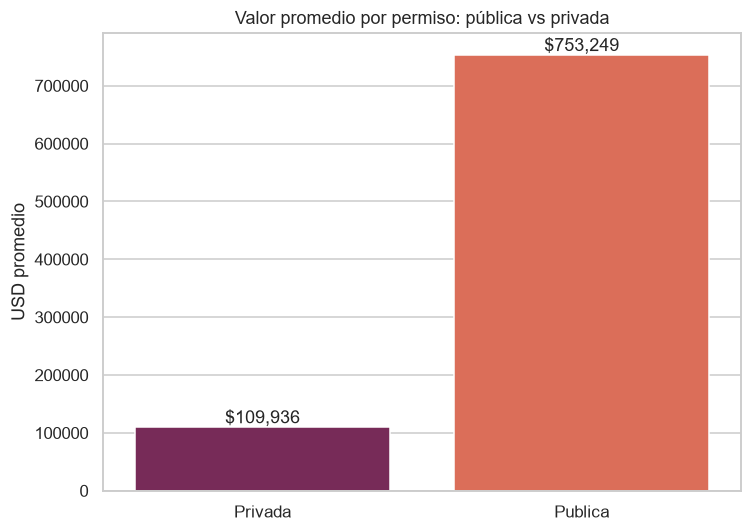

In [6]:
q5 = '''SELECT propiedad, COUNT(*) num_permisos,
        AVG(valor_edificacion_usd) valor_promedio
        FROM permisos WHERE propiedad IS NOT NULL GROUP BY propiedad'''
df5 = pd.read_sql(q5, con)
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(df5, x='propiedad', y='valor_promedio', hue='propiedad',
            palette='rocket', legend=False, ax=ax)
ax.set_title('Valor promedio por permiso: pública vs privada')
ax.set_ylabel('USD promedio'); ax.set_xlabel('')
for i, v in enumerate(df5['valor_promedio']):
    ax.text(i, v, f'${v:,.0f}', ha='center', va='bottom')
fig.tight_layout(); fig.savefig(FIG/'05_publico_privado.png', bbox_inches='tight')
df5

## 6. Estacionalidad (permisos por mes)

,mes,num_permisos
0,1,9228
1,2,7456
2,3,8607
3,4,8321
4,5,8718
5,6,8451
6,7,10434
7,8,11280
8,9,10121
9,10,10071


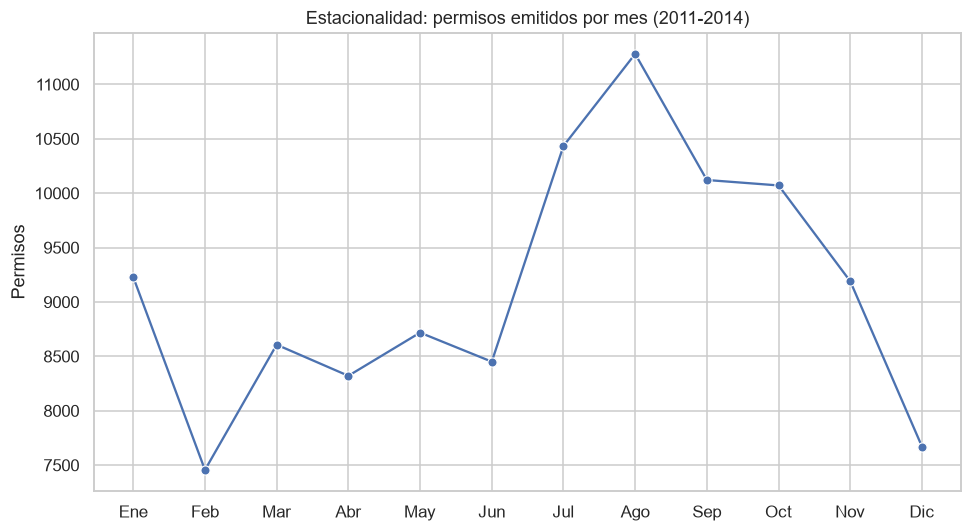

In [7]:
q7 = '''SELECT mes, COUNT(*) num_permisos FROM permisos
        WHERE mes BETWEEN 1 AND 12 GROUP BY mes ORDER BY mes'''
df7 = pd.read_sql(q7, con)
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
fig, ax = plt.subplots(figsize=(9,5))
sns.lineplot(x=df7['mes'], y=df7['num_permisos'], marker='o', ax=ax, color='#4C72B0')
ax.set_xticks(range(1,13)); ax.set_xticklabels(meses)
ax.set_title('Estacionalidad: permisos emitidos por mes (2011-2014)')
ax.set_ylabel('Permisos'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(FIG/'06_estacionalidad.png', bbox_inches='tight')
df7

## Conclusiones

- **Concentración geográfica:** Guayas y Pichincha lideran la actividad de construcción, reflejando a Guayaquil y Quito como polos económicos.
- **Hormigón armado** es el material de estructura dominante en todas las regiones.
- La **obra pública** es escasa en número pero de valor unitario mucho mayor que la privada.
- Se observan patrones de **estacionalidad** en la emisión mensual de permisos.

*Datos: INEC — Encuesta de Edificaciones 2011-2014 (CC BY 4.0).*